In [5]:
import pandas as pd

df = pd.read_excel(r'D:\Kashish\cpi_model\data\inflation.xlsx')
print(df.columns)
df.head()

Index(['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group',
       'subgroup', 'index', 'inflation', 'status'],
      dtype='object')


,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
0,2012,2025,12,December,All India,Combined,General,General-Overall,198.0,1.33,F
1,2012,2025,11,November,All India,Combined,General,General-Overall,197.9,0.71,F
2,2012,2025,10,October,All India,Combined,General,General-Overall,197.3,0.25,F
3,2012,2025,9,September,All India,Combined,General,General-Overall,197.0,1.44,F
4,2012,2025,8,August,All India,Combined,General,General-Overall,197.0,2.07,F


In [6]:
print(df.columns)

Index(['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group',
       'subgroup', 'index', 'inflation', 'status'],
      dtype='object')


In [22]:
print(df.columns.tolist())

['Date', 'Inflation']


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
# Step 1: Remove index completely (without duplicating Date)
df = df.reset_index(drop=True)

# Step 2: Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 3: Sort and set index properly (ONLY ONCE)
df = df.sort_values('Date').set_index('Date')

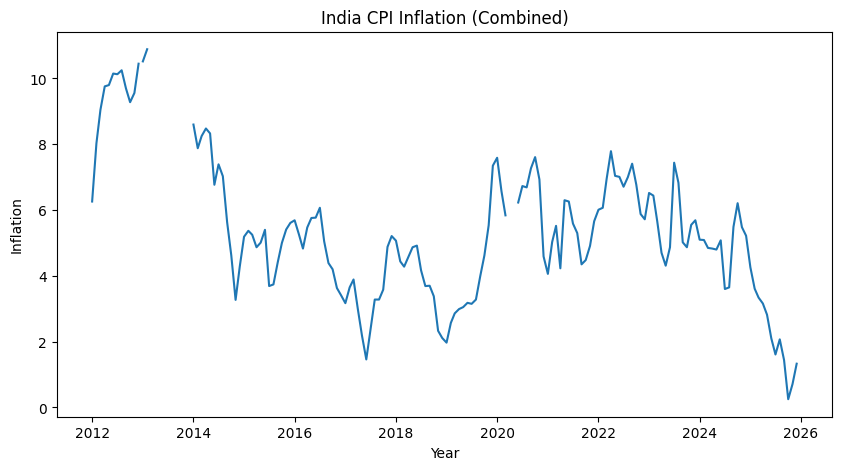

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Inflation'])
plt.title("India CPI Inflation (Combined)")
plt.xlabel("Year")
plt.ylabel("Inflation")
plt.show()

In [28]:
df.index.to_series().diff().value_counts()

Date
31 days    104
30 days     60
28 days     11
0 days       5
29 days      4
Name: count, dtype: int64

In [29]:
df = df[~df.index.duplicated(keep='first')]

In [30]:
df = df.sort_index()

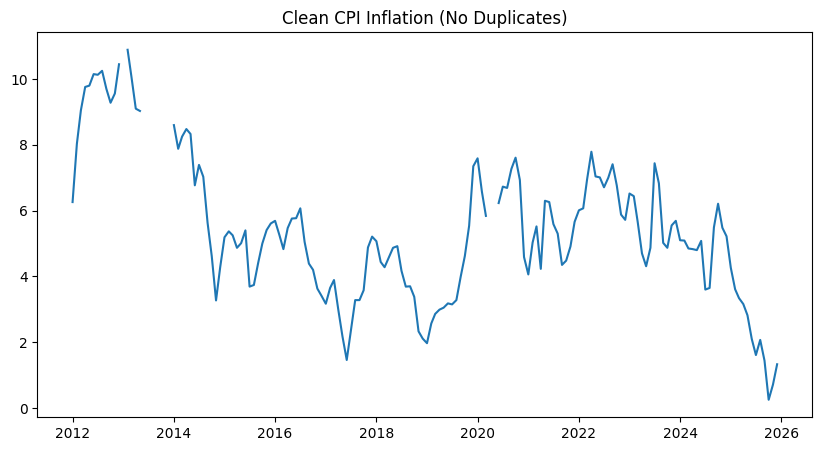

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Inflation'])
plt.title("Clean CPI Inflation (No Duplicates)")
plt.show()

In [ ]:
df = df.iloc[:-5]   

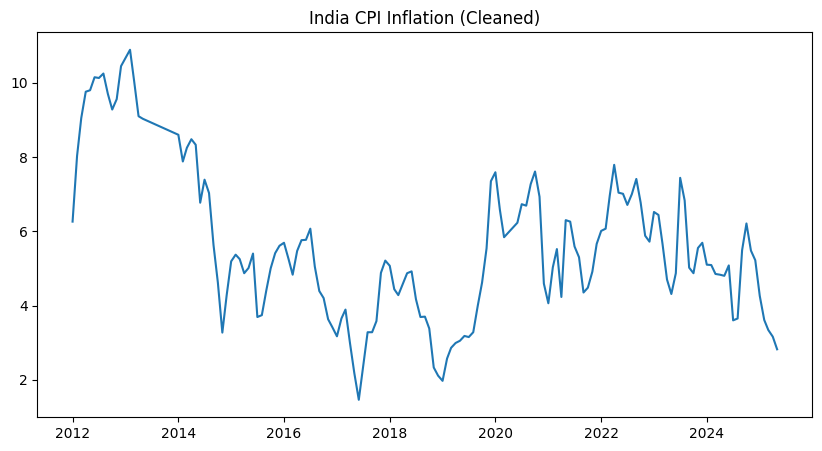

In [36]:
plt.figure(figsize=(10,5))
plt.plot(df['Inflation'])
plt.title("India CPI Inflation (Cleaned)")
plt.show()